### Get San diego cases and wastewater data

### Data

  **Cases**
- Start date: 2020
- End date: June 2023 

*Cases by catchment end date:

  **Wastewater**: 
- Start date: February 2021 (2/24/21)
- End date; November 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
print(smf)
from pathlib import Path
import covasim as cv

print(cv.__file__)
print(hasattr(cv, "Sim"))
print(cv.Sim)

<module 'statsmodels.formula.api' from '/storage/hcraddock/mamba/envs/covasim/lib/python3.10/site-packages/statsmodels/formula/api.py'>
Covasim 3.1.8 (2026-05-29) — © 2020-2026 by IDM
/storage/hcraddock/GitHub/covasim4wastewater/covasim/__init__.py
True
<class 'covasim.sim.Sim'>


In [5]:
DATA_ROOT = Path.home() / "GitHub"
WW_REPO = DATA_ROOT / "SARS-CoV-2_WasteWater_San-Diego"
CASES_REPO = DATA_ROOT / "lone_pine" / "resources"

In [6]:
#Paths
home_root = Path.home()   # parent folder of the two clones
print(home_root)
print((DATA_ROOT / "lone_pine" / "resources" / "cases.csv").exists())
print((DATA_ROOT / "SARS-CoV-2_WasteWater_San-Diego" / "PointLoma_sewage_qPCR.csv").exists())

/home/hcraddock
True
True


## Data

In [37]:
ww = pd.read_csv(WW_REPO / "PointLoma_sewage_qPCR.csv")
cases = pd.read_csv(CASES_REPO/ "cases.csv")
zips = pd.read_csv(WW_REPO / "Zipcodes.csv")

In [38]:
#Wastewater data
print(ww.shape)
print(cases.shape)
ww.head()

(782, 2)
(129059, 7)


,Sample_Date,Mean viral gene copies/L
0,2/24/21,681730
1,2/28/21,943877
2,3/1/21,1034196
3,3/3/21,1918221
4,3/7/21,770022


In [10]:
ww.tail()

,Sample_Date,Mean viral gene copies/L
777,10/28/25,2236659
778,11/16/25,1708435
779,11/17/25,564604
780,11/18/25,1530501
781,11/19/25,746268


In [11]:
print(cases.shape)
cases.head()

(129059, 7)


,updatedate,ziptext,case_count,new_cases,days_past,population,catchment
0,2020-03-31,91902.0,0.0,0.0,1179,17653,PointLoma
1,2020-03-31,92113.0,0.0,0.0,1179,56066,PointLoma
2,2020-03-31,92111.0,0.0,0.0,1179,45096,PointLoma
3,2020-03-31,92110.0,0.0,0.0,1179,25341,PointLoma
4,2020-03-31,92109.0,0.0,0.0,1179,45787,PointLoma


In [13]:
cases.tail(100)

,updatedate,ziptext,case_count,new_cases,days_past,population,catchment
128959,2023-03-17,NaN,176451.0,64.0,100,3648100,NaN
128960,2023-03-18,NaN,176467.0,16.0,99,3648100,NaN
128961,2023-03-19,NaN,176488.0,21.0,98,3648100,NaN
128962,2023-03-20,NaN,176506.0,18.0,97,3648100,NaN
128963,2023-03-21,NaN,176584.0,78.0,96,3648100,NaN
...,...,...,...,...,...,...,...
129054,2023-06-20,NaN,180069.0,27.0,5,3648100,NaN
129055,2023-06-21,NaN,180093.0,24.0,4,3648100,NaN
129056,2023-06-22,NaN,180112.0,19.0,3,3648100,NaN
129057,2023-06-23,NaN,180118.0,6.0,2,3648100,NaN


In [30]:
zips.head()

,Zip_code,Community,Wastewater_treatment_plant
0,91901,Alpine,Point Loma
1,91902,Bonita,Point Loma
2,91910,Chula Vista,Point Loma
3,91911,Chula Vista,Point Loma
4,91913,Chula Vista,Point Loma


#### Inspect cases data

In [15]:
cases["updatedate"] = pd.to_datetime(cases["updatedate"])

# Date range and row count for each catchment value, including NaN
print(cases.groupby("catchment", dropna=False)["updatedate"].agg(["min", "max", "count"]))

                 min        max  count
catchment                             
Encina    2020-03-31 2023-06-17  20968
Other     2020-03-31 2023-06-17  31032
PointLoma 2020-03-31 2023-06-17  72339
SouthBay  2020-03-31 2023-06-17   3519
NaN       2020-03-11 2023-06-24   1201


In [ ]:
# Are the NaN-catchment rows all county-wide rows?
na = cases[cases["catchment"].isna()]
print(na["ziptext"].isna().all(), na["population"].unique())

# Where the NaN block starts in the file (row position) and in time
first_na_idx = na.index.min()
print(first_na_idx, cases.loc[first_na_idx, "updatedate"])
print(cases.loc[first_na_idx - 2:first_na_idx + 2])

# Last date with zip-level data
zip_level = cases.dropna(subset=["ziptext"])
print(zip_level["updatedate"].min(), zip_level["updatedate"].max())

## Merge data

##### 1. Cases + zip code

In [16]:
cases = cases.dropna(subset=["ziptext"]).copy()
cases["zip"] = cases["ziptext"].astype(int)

In [17]:
cases["zip"] = cases["ziptext"].astype(int)

In [18]:
cases.head()

,updatedate,ziptext,case_count,new_cases,days_past,population,catchment,zip
0,2020-03-31,91902.0,0.0,0.0,1179,17653,PointLoma,91902
1,2020-03-31,92113.0,0.0,0.0,1179,56066,PointLoma,92113
2,2020-03-31,92111.0,0.0,0.0,1179,45096,PointLoma,92111
3,2020-03-31,92110.0,0.0,0.0,1179,25341,PointLoma,92110
4,2020-03-31,92109.0,0.0,0.0,1179,45787,PointLoma,92109


In [19]:
# Zip-side key
zips["zip"] = zips["Zip_code"].astype(int)

In [27]:
# Join
df_merged = cases.merge(
    zips[["zip", "Community", "Wastewater_treatment_plant"]],
    on="zip",
    how="left",
    validate="m:1",   # many case rows per zip, one zip row per zip
)

In [28]:
# Check the join worked
print(df_merged.shape, cases.shape)

(127858, 10) (127858, 8)


In [29]:
print(df_merged["Wastewater_treatment_plant"].isna().sum() , "case rows with no plant match")

31032 case rows with no plant match


In [30]:
print(df_merged["Wastewater_treatment_plant"].value_counts(dropna=False))

Wastewater_treatment_plant
Point Loma    72339
NaN           31032
Encina        20968
South Bay      3519
Name: count, dtype: int64


#### Certain date - after which there is no waste-water data

In [31]:
df_merged.head()

,updatedate,ziptext,case_count,new_cases,days_past,population,catchment,zip,Community,Wastewater_treatment_plant
0,2020-03-31,91902.0,0.0,0.0,1179,17653,PointLoma,91902,Bonita,Point Loma
1,2020-03-31,92113.0,0.0,0.0,1179,56066,PointLoma,92113,San Diego,Point Loma
2,2020-03-31,92111.0,0.0,0.0,1179,45096,PointLoma,92111,San Diego,Point Loma
3,2020-03-31,92110.0,0.0,0.0,1179,25341,PointLoma,92110,San Diego,Point Loma
4,2020-03-31,92109.0,0.0,0.0,1179,45787,PointLoma,92109,San Diego,Point Loma


#### Check waste-water data + cases data match

In [32]:
def norm(s):
    return s.str.lower().str.replace(r"[^a-z]", "", regex=True)

df_merged["catch_n"] = norm(df_merged["catchment"])
df_merged["plant_n"] = norm(df_merged["Wastewater_treatment_plant"])

print(pd.crosstab(df_merged["catchment"], df_merged["Wastewater_treatment_plant"], dropna=False))

both = df_merged.dropna(subset=["catchment", "Wastewater_treatment_plant"])
print("all agree:", (both["catch_n"] == both["plant_n"]).all())

# Show any disagreements at the zip level
bad = both[both["catch_n"] != both["plant_n"]]
print(bad[["zip", "catchment", "Wastewater_treatment_plant"]].drop_duplicates())

Wastewater_treatment_plant  Encina  Point Loma  South Bay    NaN
catchment                                                       
Encina                       20968           0          0      0
Other                            0           0          0  31032
PointLoma                        0       72339          0      0
SouthBay                         0           0       3519      0
all agree: True
Empty DataFrame
Columns: [zip, catchment, Wastewater_treatment_plant]
Index: []


In [33]:
a = set(df_merged.loc[df_merged["catchment"] == "PointLoma", "zip"])
b = set(zips.loc[zips["Wastewater_treatment_plant"] == "Point Loma", "zip"])
print(a == b, a ^ b)   # True, set() means identical

False {92152}


In [34]:
print("in cases only:", 92152 in a and 92152 not in b)
print("in Zipcodes only:", 92152 in b and 92152 not in a)

# How much does it matter?
z = df_merged[df_merged["zip"] == 92152]
print(z["catchment"].unique(), z["population"].max())
print("cases from this zip:", z["new_cases"].sum())
print("share of Point Loma cases:", z["new_cases"].sum() / df_merged.loc[df_merged["catchment"] == "PointLoma", "new_cases"].sum())

in cases only: False
in Zipcodes only: True
[] nan
cases from this zip: 0.0
share of Point Loma cases: 0.0


#### Extract Point Loma

In [22]:
cases["updatedate"] = pd.to_datetime(cases["updatedate"])

In [23]:
cases_pl = cases[cases["catchment"] == "PointLoma"]

In [24]:
cases_pl.tail()

,updatedate,ziptext,case_count,new_cases,days_past,population,catchment,zip
127832,2023-06-13,92182.0,209.857143,0.0,10,606,PointLoma,92182
127833,2023-06-14,92182.0,209.857143,0.0,9,606,PointLoma,92182
127834,2023-06-15,92182.0,209.857143,0.0,8,606,PointLoma,92182
127835,2023-06-16,92182.0,209.857143,0.0,7,606,PointLoma,92182
127836,2023-06-17,92182.0,209.857143,0.0,6,606,PointLoma,92182


In [26]:
ww.tail(10)

,Sample_Date,Mean viral gene copies/L
772,10/13/25,2459831
773,10/14/25,1084017
774,10/15/25,1536859
775,10/26/25,2220045
776,10/27/25,2112956
777,10/28/25,2236659
778,11/16/25,1708435
779,11/17/25,564604
780,11/18/25,1530501
781,11/19/25,746268


In [39]:
ww.head(10)

,Sample_Date,Mean viral gene copies/L
0,2/24/21,681730
1,2/28/21,943877
2,3/1/21,1034196
3,3/3/21,1918221
4,3/7/21,770022
5,3/8/21,915980
6,3/10/21,254601
7,3/14/21,2743479
8,3/15/21,1494301
9,3/17/21,1982980


In [45]:
cases_pl.tail(10)

,updatedate,ziptext,case_count,new_cases,days_past,population,catchment,zip
127813,2023-06-15,92155.0,107.857143,0.0,8,550,PointLoma,92155
127814,2023-06-16,92155.0,107.857143,0.0,7,550,PointLoma,92155
127815,2023-06-17,92155.0,107.857143,0.0,6,550,PointLoma,92155
127830,2023-06-11,92182.0,209.857143,0.0,12,606,PointLoma,92182
127831,2023-06-12,92182.0,209.857143,0.0,11,606,PointLoma,92182
127832,2023-06-13,92182.0,209.857143,0.0,10,606,PointLoma,92182
127833,2023-06-14,92182.0,209.857143,0.0,9,606,PointLoma,92182
127834,2023-06-15,92182.0,209.857143,0.0,8,606,PointLoma,92182
127835,2023-06-16,92182.0,209.857143,0.0,7,606,PointLoma,92182
127836,2023-06-17,92182.0,209.857143,0.0,6,606,PointLoma,92182


In [ ]:
#### Cases per 100,000

#### Cases per 100,000

In [49]:
# One population value per zip (check it is constant over time)
print(cases_pl.groupby("zip")["population"].nunique().max(), "max distinct population values per zip")


1 max distinct population values per zip


In [50]:
zip_pop = cases_pl.groupby("zip")["population"].max()
CATCHMENT_POP = zip_pop.sum()
print("Point Loma catchment population:", CATCHMENT_POP)

Point Loma catchment population: 2116170


### Plot

In [46]:
cases_pl = cases_pl.copy()
cases_pl["updatedate"] = pd.to_datetime(cases_pl["updatedate"])

daily = (cases_pl.groupby("updatedate", as_index=False)
                 .agg(case_count=("case_count", "sum"),
                      new_cases=("new_cases", "sum"),
                      n_zips=("zip", "nunique")))

print(daily.shape)
print(daily.tail())
print(daily["n_zips"].describe())   # should be roughly constant

(1174, 4)
     updatedate     case_count  new_cases  n_zips
1169 2023-06-13  654270.142857   0.714286      62
1170 2023-06-14  654270.857143   0.714286      62
1171 2023-06-15  654271.571429   0.714286      62
1172 2023-06-16  654272.285714   0.714286      62
1173 2023-06-17  654273.000000   0.714286      62
count    1174.000000
mean       61.617547
std         1.030349
min        55.000000
25%        62.000000
50%        62.000000
75%        62.000000
max        62.000000
Name: n_zips, dtype: float64


In [47]:
print(daily.loc[daily["n_zips"] < 62, ["updatedate", "n_zips"]])

    updatedate  n_zips
0   2020-03-31      55
1   2020-04-01      55
2   2020-04-02      56
3   2020-04-03      57
4   2020-04-04      57
..         ...     ...
172 2020-09-19      61
173 2020-09-20      61
174 2020-09-21      61
175 2020-09-22      61
176 2020-09-23      61

[177 rows x 2 columns]


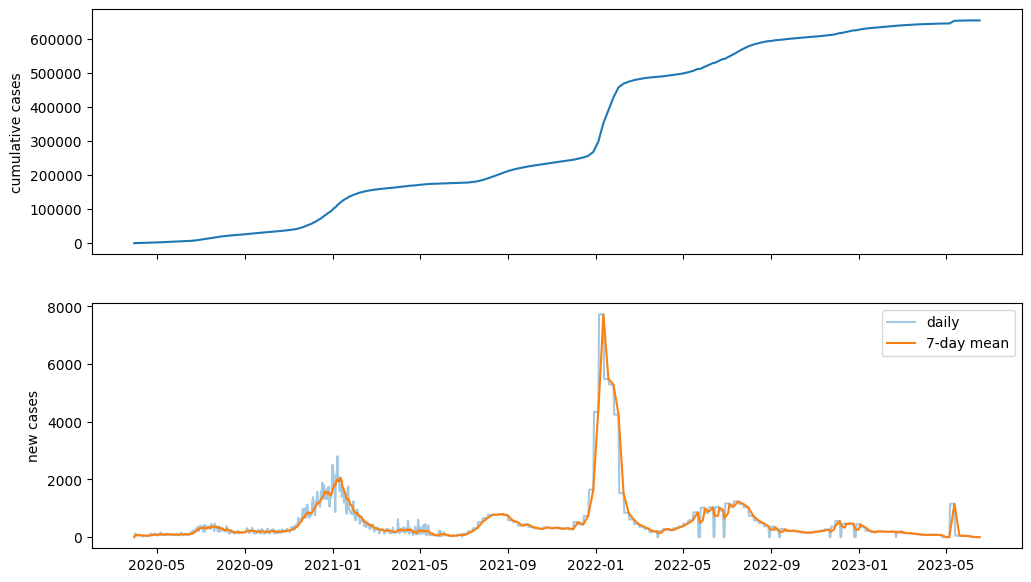

In [48]:
### Plot
fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax[0].plot(daily["updatedate"], daily["case_count"])
ax[0].set_ylabel("cumulative cases")
ax[1].plot(daily["updatedate"], daily["new_cases"], alpha=0.4, label="daily")
ax[1].plot(daily["updatedate"], daily["new_cases"].rolling(7, min_periods=1).mean(), label="7-day mean")
ax[1].set_ylabel("new cases")
ax[1].legend()
plt.show()

#### Cases per 100,000

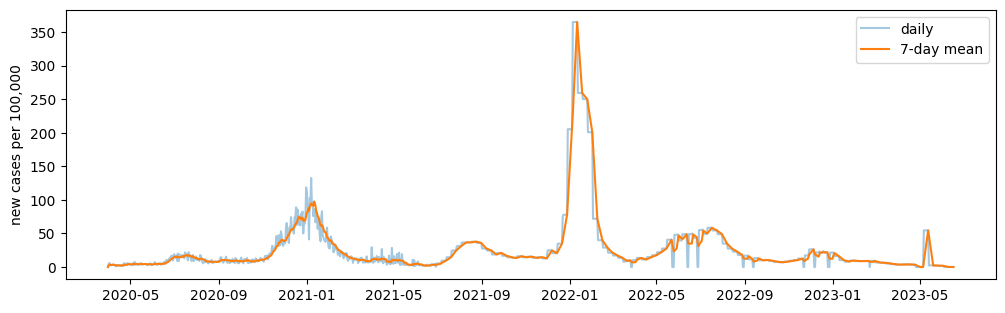

In [51]:
daily["new_cases_per_100k"] = daily["new_cases"] / CATCHMENT_POP * 100_000
daily["case_count_per_100k"] = daily["case_count"] / CATCHMENT_POP * 100_000

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(daily["updatedate"], daily["new_cases_per_100k"], alpha=0.4, label="daily")
ax.plot(daily["updatedate"], daily["new_cases_per_100k"].rolling(7, min_periods=1).mean(), label="7-day mean")
ax.set_ylabel("new cases per 100,000")
ax.legend()
plt.show()

#### Start in February 2021; when wastewater starts

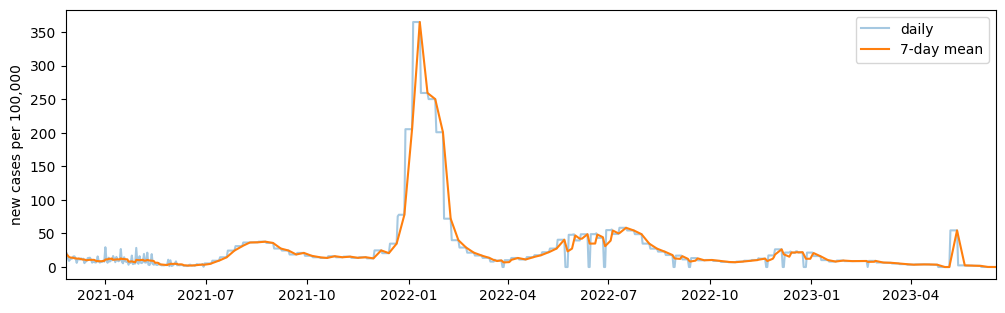

In [53]:
START = pd.Timestamp("2021-02-24")

d = daily[daily["updatedate"] >= START]

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(d["updatedate"], d["new_cases_per_100k"], alpha=0.4, label="daily")
ax.plot(d["updatedate"], d["new_cases_per_100k"].rolling(7, min_periods=1).mean(), label="7-day mean")
ax.set_ylabel("new cases per 100,000")
ax.set_xlim(START, d["updatedate"].max())
ax.legend()
plt.show()

### 2. Process waste-water data

In [55]:
#Date format
ww["date"] = pd.to_datetime(ww["Sample_Date"], format="%m/%d/%y")

#Rename variable
ww = ww.rename(columns={"Mean viral gene copies/L": "ww_copies_per_L"})

In [56]:
ww.head()

,Sample_Date,ww_copies_per_L,date
0,2/24/21,681730,2021-02-24
1,2/28/21,943877,2021-02-28
2,3/1/21,1034196,2021-03-01
3,3/3/21,1918221,2021-03-03
4,3/7/21,770022,2021-03-07


In [61]:
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=range(1, 13, 2)))   # Jan, Mar, May, Jul, Sep, Nov

def month_year(x, pos=None):
    d = mdates.num2date(x)
    return d.strftime("%b\n%Y") if d.month == 1 else d.strftime("%b")

ax.xaxis.set_major_formatter(FuncFormatter(month_year))

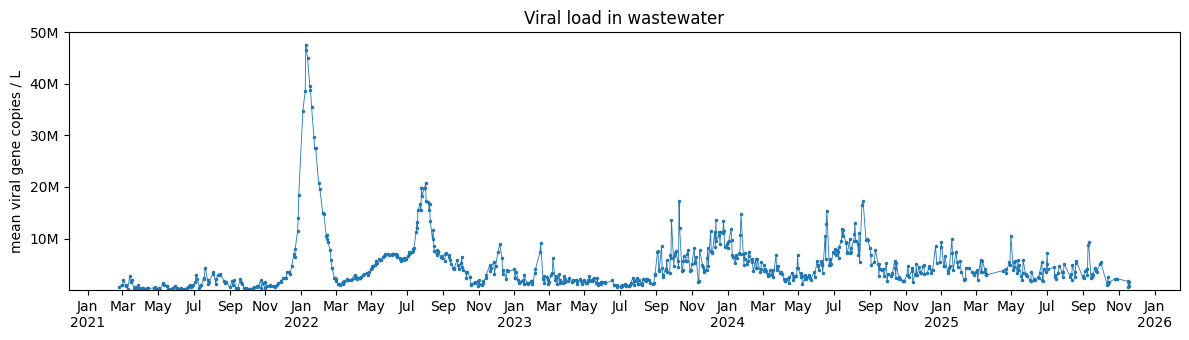

In [62]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

ww_plot = ww.sort_values("date")

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(ww_plot["date"], ww_plot["ww_copies_per_L"], ".-", ms=3, lw=0.6)

ax.set_yticks([10e6, 20e6, 30e6, 40e6, 50e6])
ax.set_yticklabels(["10M", "20M", "30M", "40M", "50M"])
ax.set_ylim(0, 50e6)

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=range(1, 13, 2)))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: 
    mdates.num2date(x).strftime("%b\n%Y") if mdates.num2date(x).month == 1
    else mdates.num2date(x).strftime("%b")))

ax.set_title("Viral load in wastewater")
ax.set_ylabel("mean viral gene copies / L")
plt.tight_layout()
plt.show()

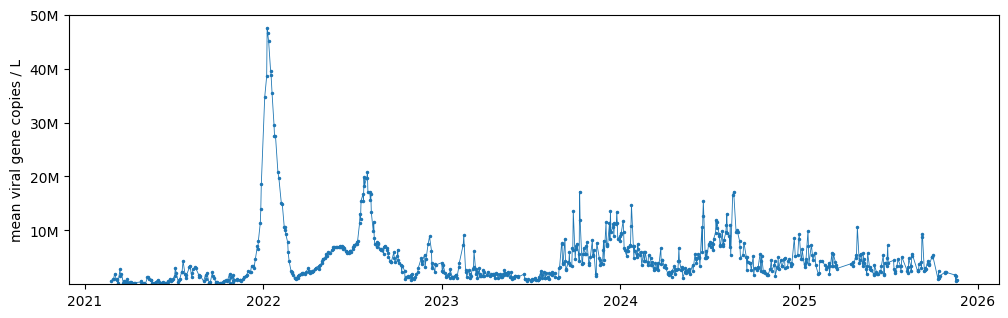

In [58]:
ww_plot = ww.sort_values("date")

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(ww_plot["date"], ww_plot["ww_copies_per_L"], ".-", ms=3, lw=0.6)

ticks = [10e6, 20e6, 30e6, 40e6, 50e6]
ax.set_yticks(ticks)
ax.set_yticklabels(["10M", "20M", "30M", "40M", "50M"])
ax.set_ylim(0, 50e6)

ax.set_ylabel("mean viral gene copies / L")
plt.show()

### Plot both

In [75]:
from matplotlib.ticker import FuncFormatter, FixedLocator

In [70]:
def month_year(x, pos):
    d = mdates.num2date(x)
    if d.month == 1 or pos == 0:      # January, or the first tick on the axis
        return d.strftime("%b\n%Y")
    return d.strftime("%b")

ax.xaxis.set_major_formatter(FuncFormatter(month_year))

In [73]:
## Data
START = pd.Timestamp("2021-02-24")
END = daily["updatedate"].max()

d = daily[daily["updatedate"] >= START]
ww_plot = ww.sort_values("date")
ww_plot = ww_plot[(ww_plot["date"] >= START) & (ww_plot["date"] <= END)]

In [78]:
# Ticks: the start date, then every second month from May (May, Jul, Sep, Nov, Jan, ...)
ticks = [START] + list(pd.date_range("2021-05-01", END, freq="2MS"))
ax.xaxis.set_major_locator(FixedLocator(mdates.date2num(ticks)))

def month_year(x, pos):
    d = mdates.num2date(x)
    if pos == 0 or d.month == 1:          # first tick (Feb 2021) or any January
        return d.strftime("%b\n%Y")
    return d.strftime("%b")

ax.xaxis.set_major_formatter(FuncFormatter(month_year))
ax.set_xlim(START, END)

(18682.0, 19525.0)

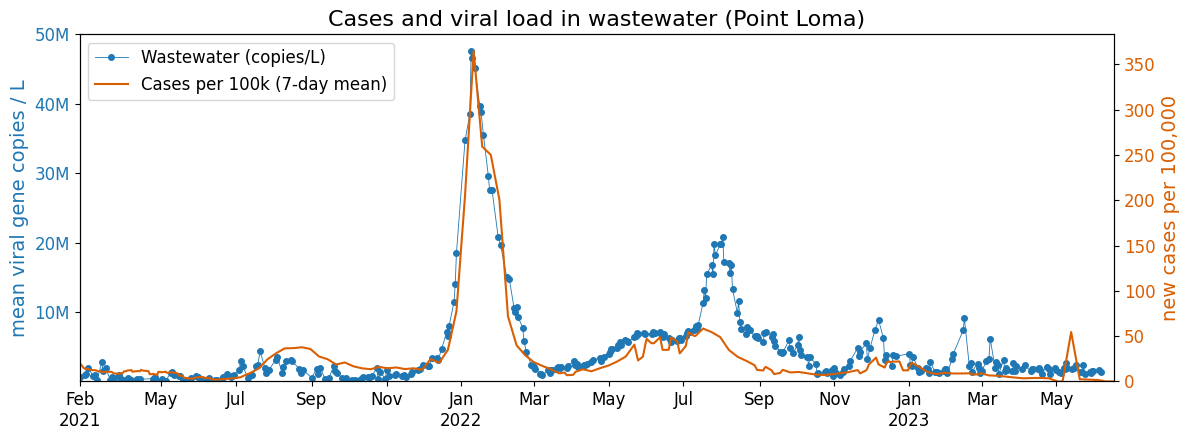

In [80]:
## Data
START = pd.Timestamp("2021-02-24")
END = daily["updatedate"].max()

d = daily[daily["updatedate"] >= START]
ww_plot = ww.sort_values("date")
ww_plot = ww_plot[(ww_plot["date"] >= START) & (ww_plot["date"] <= END)]

## Figure (create this BEFORE touching ax)
fig, ax = plt.subplots(figsize=(12, 4.5))

# Left axis: wastewater
c_ww = "tab:blue"
l1, = ax.plot(ww_plot["date"], ww_plot["ww_copies_per_L"], ".-", ms=8, lw=0.6,
              color=c_ww, label="Wastewater (copies/L)")
ax.set_ylabel("mean viral gene copies / L", color=c_ww, fontsize=14)
ax.set_yticks([10e6, 20e6, 30e6, 40e6, 50e6])
ax.set_yticklabels(["10M", "20M", "30M", "40M", "50M"])
ax.set_ylim(0, 50e6)
ax.tick_params(axis="y", labelcolor=c_ww, labelsize=12)

# Right axis: cases
ax2 = ax.twinx()
c_cases = "#D95F02"
l2, = ax2.plot(d["updatedate"], d["new_cases_per_100k"].rolling(7, min_periods=1).mean(),
               color=c_cases, lw=1.5, label="Cases per 100k (7-day mean)")
ax2.set_ylabel("new cases per 100,000", color=c_cases, fontsize=14)
ax2.set_ylim(bottom=0)
ax2.tick_params(axis="y", labelcolor=c_cases, labelsize=12)

# X axis: Feb 2021 at the start, then every second month from May
ticks = [START] + list(pd.date_range("2021-05-01", END, freq="2MS"))
ax.xaxis.set_major_locator(FixedLocator(mdates.date2num(ticks)))

def month_year(x, pos):
    dt = mdates.num2date(x)
    if pos == 0 or dt.month == 1:      # first tick or any January
        return dt.strftime("%b\n%Y")
    return dt.strftime("%b")

ax.xaxis.set_major_formatter(FuncFormatter(month_year))
ax.set_xlim(START, END)
ax.tick_params(axis="x", labelsize=12)

ax.set_title("Cases and viral load in wastewater (Point Loma)", fontsize=16)
ax.legend(handles=[l1, l2], loc="upper left", fontsize=12)

plt.tight_layout()
plt.show()

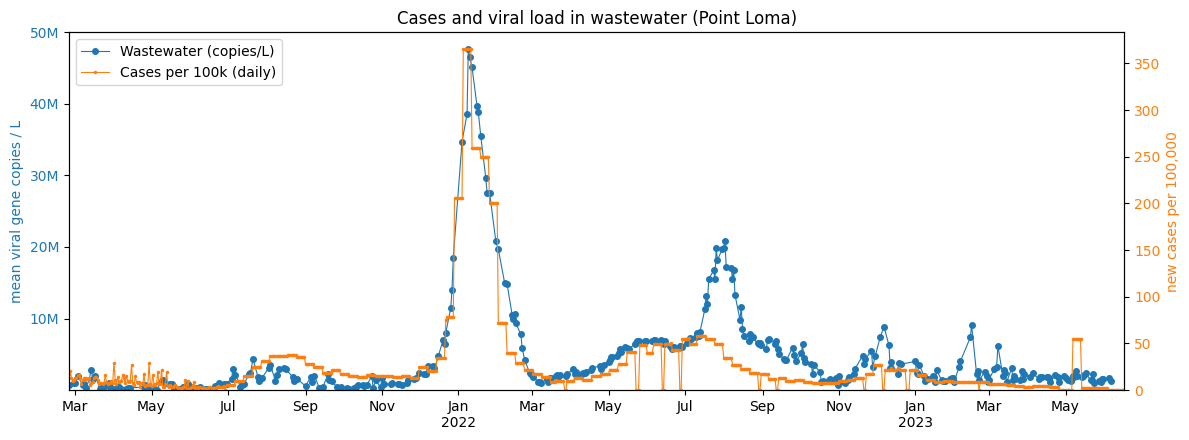

In [64]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import pandas as pd

START = pd.Timestamp("2021-02-24")
END = daily["updatedate"].max()

d = daily[daily["updatedate"] >= START]
ww_plot = ww.sort_values("date")
ww_plot = ww_plot[(ww_plot["date"] >= START) & (ww_plot["date"] <= END)]

fig, ax = plt.subplots(figsize=(12, 4.5))

# Left axis: wastewater (bigger blue dots)
c_ww = "tab:blue"
l1, = ax.plot(ww_plot["date"], ww_plot["ww_copies_per_L"], ".-", ms=8, lw=0.8,
              color=c_ww, label="Wastewater (copies/L)")
ax.set_ylabel("mean viral gene copies / L", color=c_ww)
ax.set_yticks([10e6, 20e6, 30e6, 40e6, 50e6])
ax.set_yticklabels(["10M", "20M", "30M", "40M", "50M"])
ax.set_ylim(0, 50e6)
ax.tick_params(axis="y", labelcolor=c_ww)

# Right axis: daily cases (small orange dots + line)
ax2 = ax.twinx()
c_cases = "tab:orange"
l2, = ax2.plot(d["updatedate"], d["new_cases_per_100k"], ".-", ms=3, lw=0.8,
               color=c_cases, label="Cases per 100k (daily)")
ax2.set_ylabel("new cases per 100,000", color=c_cases)
ax2.set_ylim(bottom=0)
ax2.tick_params(axis="y", labelcolor=c_cases)

# X axis: every second month, year only in January
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=range(1, 13, 2)))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos:
    mdates.num2date(x).strftime("%b\n%Y") if mdates.num2date(x).month == 1
    else mdates.num2date(x).strftime("%b")))
ax.set_xlim(START, END)

ax.set_title("Cases and viral load in wastewater (Point Loma)")
ax.legend(handles=[l1, l2], loc="upper left")
plt.tight_layout()
plt.show()

2025-11-19 00:00:00 47626166


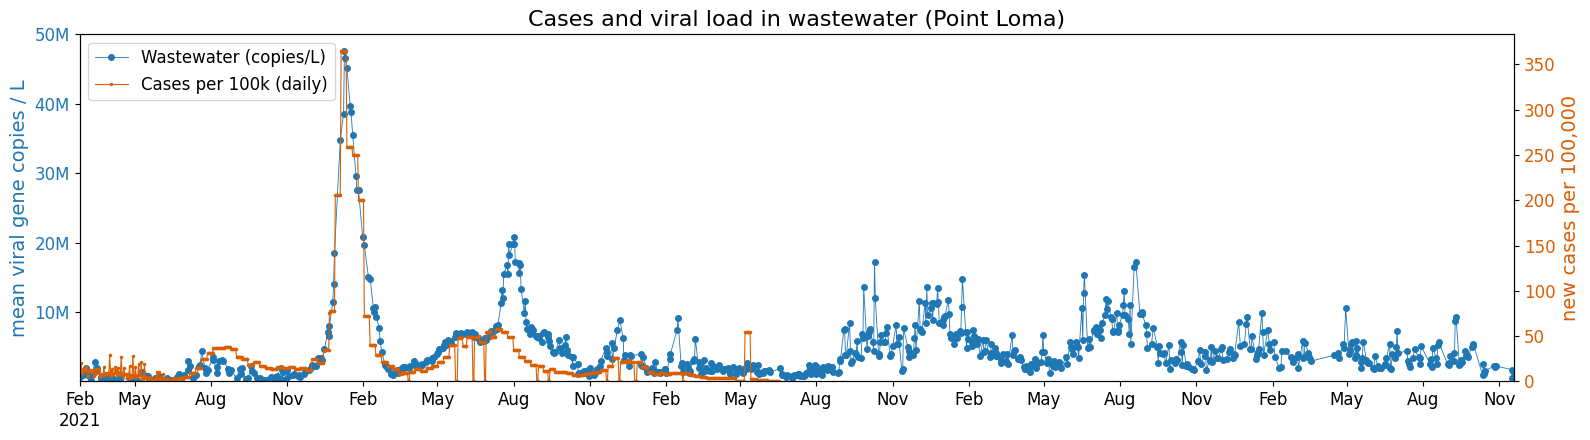

In [83]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter, FixedLocator
import pandas as pd

## Data
START = pd.Timestamp("2021-02-24")
CASES_END = daily["updatedate"].max()          # 2023-06-17
END = ww["date"].max()                         # 2025-11-19

d = daily[daily["updatedate"] >= START]
ww_plot = ww.sort_values("date")
ww_plot = ww_plot[(ww_plot["date"] >= START) & (ww_plot["date"] <= END)]

print(ww_plot["date"].max(), ww_plot["ww_copies_per_L"].max())   # check the end date and the peak

## Figure
fig, ax = plt.subplots(figsize=(16, 4.5))

# Left axis: wastewater (bigger blue dots)
c_ww = "tab:blue"
l1, = ax.plot(ww_plot["date"], ww_plot["ww_copies_per_L"], ".-", ms=8, lw=0.6,
              color=c_ww, label="Wastewater (copies/L)")
ax.set_ylabel("mean viral gene copies / L", color=c_ww, fontsize=14)
ax.set_yticks([10e6, 20e6, 30e6, 40e6, 50e6])
ax.set_yticklabels(["10M", "20M", "30M", "40M", "50M"])
ax.set_ylim(0, 50e6)
ax.tick_params(axis="y", labelcolor=c_ww, labelsize=12)

# Right axis: daily cases (small orange dots + line)
ax2 = ax.twinx()
c_cases = "#D95F02"
l2, = ax2.plot(d["updatedate"], d["new_cases_per_100k"], ".-", ms=3, lw=0.8,
               color=c_cases, label="Cases per 100k (daily)")
ax2.set_ylabel("new cases per 100,000", color=c_cases, fontsize=14)
ax2.set_ylim(bottom=0)
ax2.tick_params(axis="y", labelcolor=c_cases, labelsize=12)

# X axis: Feb 2021 at the start, then every third month from May 2021
ticks = [START] + list(pd.date_range("2021-05-01", END, freq="3MS"))
ax.xaxis.set_major_locator(FixedLocator(mdates.date2num(ticks)))

def month_year(x, pos):
    dt = mdates.num2date(x)
    if pos == 0 or dt.month == 1:
        return dt.strftime("%b\n%Y")
    return dt.strftime("%b")

ax.xaxis.set_major_formatter(FuncFormatter(month_year))
ax.set_xlim(START, END)
ax.tick_params(axis="x", labelsize=12)

ax.set_title("Cases and viral load in wastewater (Point Loma)", fontsize=16)
ax.legend(handles=[l1, l2], loc="upper left", fontsize=12)

plt.tight_layout()
plt.show()


### Plot all the waste-water data

2025-11-19 00:00:00 47626166


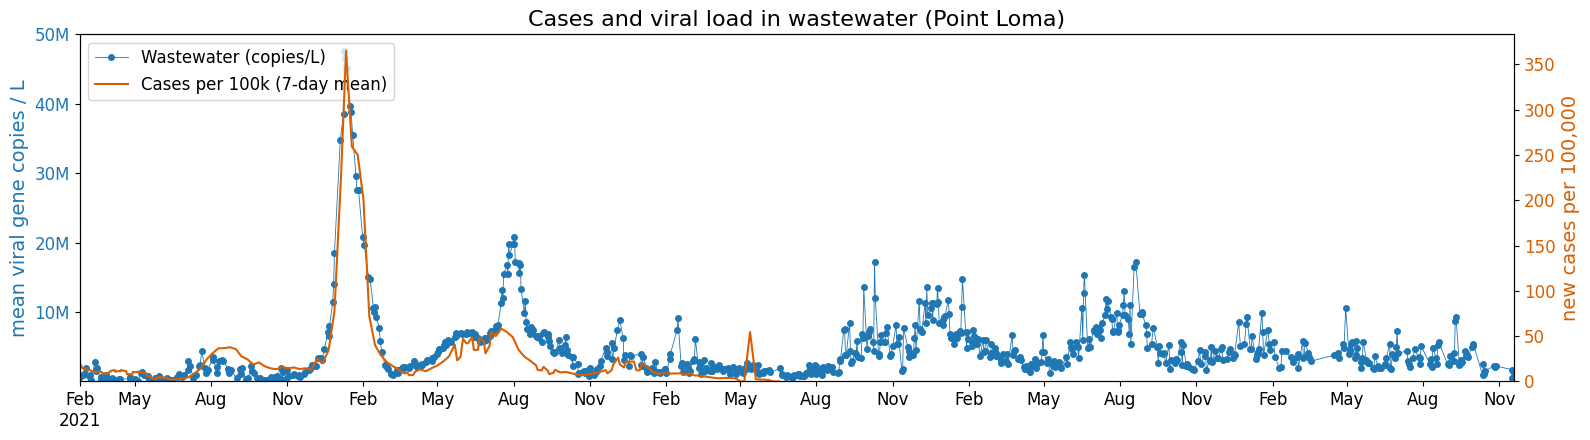

In [82]:

## Data
START = pd.Timestamp("2021-02-24")
CASES_END = daily["updatedate"].max()          # 2023-06-17
END = ww["date"].max()                         # 2025-11-19

d = daily[daily["updatedate"] >= START]
ww_plot = ww.sort_values("date")
ww_plot = ww_plot[(ww_plot["date"] >= START) & (ww_plot["date"] <= END)]

print(ww_plot["date"].max(), ww_plot["ww_copies_per_L"].max())   # check the end date and the peak

## Figure
fig, ax = plt.subplots(figsize=(16, 4.5))

# Left axis: wastewater
c_ww = "tab:blue"
l1, = ax.plot(ww_plot["date"], ww_plot["ww_copies_per_L"], ".-", ms=8, lw=0.6,
              color=c_ww, label="Wastewater (copies/L)")
ax.set_ylabel("mean viral gene copies / L", color=c_ww, fontsize=14)
ax.set_yticks([10e6, 20e6, 30e6, 40e6, 50e6])
ax.set_yticklabels(["10M", "20M", "30M", "40M", "50M"])
ax.set_ylim(0, 50e6)
ax.tick_params(axis="y", labelcolor=c_ww, labelsize=12)

# Right axis: cases
ax2 = ax.twinx()
c_cases = "#D95F02"
l2, = ax2.plot(d["updatedate"], d["new_cases_per_100k"].rolling(7, min_periods=1).mean(),
               color=c_cases, lw=1.5, label="Cases per 100k (7-day mean)")
ax2.set_ylabel("new cases per 100,000", color=c_cases, fontsize=14)
ax2.set_ylim(bottom=0)
ax2.tick_params(axis="y", labelcolor=c_cases, labelsize=12)

# X axis: Feb 2021 at the start, then every third month from Apr 2021
ticks = [START] + list(pd.date_range("2021-05-01", END, freq="3MS"))
ax.xaxis.set_major_locator(FixedLocator(mdates.date2num(ticks)))

def month_year(x, pos):
    dt = mdates.num2date(x)
    if pos == 0 or dt.month == 1:
        return dt.strftime("%b\n%Y")
    return dt.strftime("%b")

ax.xaxis.set_major_formatter(FuncFormatter(month_year))
ax.set_xlim(START, END)
ax.tick_params(axis="x", labelsize=12)

ax.set_title("Cases and viral load in wastewater (Point Loma)", fontsize=16)
ax.legend(handles=[l1, l2], loc="upper left", fontsize=12)

plt.tight_layout()
plt.show()

### 2. Join cases + waste-water data

In [ ]:
#Date format
ww["date"] = pd.to_datetime(ww["Sample_Date"], format="%m/%d/%y")

#Rename variable
ww = ww.rename(columns={"Mean viral gene copies/L": "ww_copies_per_L"})

ww_daily = ww.groupby("date", as_index=False)["ww_copies_per_L"].mean()

In [81]:
ww.tail()

,Sample_Date,ww_copies_per_L,date
777,10/28/25,2236659,2025-10-28
778,11/16/25,1708435,2025-11-16
779,11/17/25,564604,2025-11-17
780,11/18/25,1530501,2025-11-18
781,11/19/25,746268,2025-11-19


In [ ]:
pl = cases[cases["catchment"] == "PointLoma"].copy()
pl["updatedate"] = pd.to_datetime(pl["updatedate"])
daily = (pl.groupby("updatedate", as_index=False)
           .agg(new_cases=("new_cases", "sum"))
           .rename(columns={"updatedate": "date"}))

joined = daily.merge(ww_daily, on="date", how="left")

print("cases:", daily["date"].min(), daily["date"].max())
print("wastewater:", ww_daily["date"].min(), ww_daily["date"].max())
print(joined["ww_copies_per_L"].notna().sum(), "days with both")

# Is new_cases already smoothed?
print("integer counts:", daily["new_cases"].round().eq(daily["new_cases"]).all())
print((daily["new_cases"] < 0).sum(), "negative days")